## Imports and Environment Setup

In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')
    
import numpy as np
import healpy as hp
import glob
import matplotlib
matplotlib.rcParams.update({'font.size':20})
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from pylab import rcParams
from matplotlib import rc;rc('text', usetex=True);rc('font', weight='bold');matplotlib.rcParams['text.latex.preamble']
rcParams['axes.facecolor'] = 'white'
rcParams['font.family'] = 'serif'
rc('text.latex',preamble=r'\usepackage{/sptlocal/user/kevinlevy/summerfield_lensing/notebooks/apjfonts}')
from matplotlib import gridspec
from astropy.io import fits
from astropy.wcs import WCS
from astropy import units as u

import sys, os
sys.path.append("/sptlocal/user/kevinlevy/spt3g_software/build/")
sys.path.append("/sptlocal/user/kevinlevy/spt3g_software/mapspectra/python")
from spt3g import core, maps

## Configurations

In [2]:
freq_arr = [90, 150, 220]
field_arr = ["summer-a", "summer-b", "summer-c"]
nside=2048
lmax = 4000

beam_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/'
beam_file = 'compiled_2020_beam_freqghz.npy'

apod_mask_dic = {}
for field in field_arr:
    apod_mask = hp.read_map('/sptlocal/user/kevinlevy/summerfield_lensing/data/masks/border_mask_%s.fits'%(field)) 
    apod_mask[apod_mask == hp.UNSEEN] = None
    apod_mask[apod_mask == 0] = None
    apod_mask_dic[field] = apod_mask

ps20mJy_mask_file = '/sptlocal/user/kevinlevy/summerfield_lensing/data/masks/apod_mask_45arcmin_15arcmin_%s_20mJy.fits'
ps20mJy_mask_dic = {}
for field in field_arr:
    apod_ps_mask = hp.read_map(ps20mJy_mask_file %(field))
    apod_ps_mask[apod_ps_mask == hp.UNSEEN] = 0.
    ps20mJy_mask_dic[field] = apod_ps_mask

data_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/coadds/full/maps/fieldname/full/'
data_file = 'full_coadd.g3.gz'

noise_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/sims/noise/maps/fieldname/full/'
noise_file = 'no_signflip_bundle_000.g3.gz'

cl_theory_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/sims/cmb/spectra/'
cl_theory_file = 'planck2018_base_plikHM_TTTEEE_lowl_lowE_lensing_lensedCls.dat'
ell = np.loadtxt(cl_theory_loc+cl_theory_file, unpack=True)[0][:lmax]
dl_theory = np.loadtxt(cl_theory_loc+cl_theory_file, unpack=True)[1][:lmax]
conv = 2.0*np.pi/(ell**2+ell)
cls_theory = (dl_theory*conv)
dl_fac = 2.0*np.pi/(ell**2+ell)

# for plotting
labelsize = 17
legendsize = 15
color_arr = ['steelblue', 'goldenrod', 'lightseagreen', 'maroon', 'darkorchid', 'dimgray']  

nbr_pix_dic = {"summer-a":[2200, 1750], "summer-b":[2200, 1750], "summer-c":[3250, 2725]}

cntr_dic = {"summer-a":[75, -46.75], "summer-b":[25, -36], "summer-c":[187.5, -38.5]}  
ra_dic = {'summer-a':[50, 62.5, 75, 87.5, 100], 
          'summer-b':[0, 12.5, 25, 37.5, 50], 
          'summer-c':[150, 187.5, 225]}
dec_dic = {'summer-a':[-63,-56, -49, -42, -35.875, -31.375, -28.125],            
           'summer-b':[-42, -38.5, -35, -31.5, -28], 
           'summer-c':[-42, -38.5, -35, -31.5, -28]}

reso_arcmin = 1.45 #hp.nside2resol(2048, arcmin = True)
axis_label_arr = [['RA', 'DEC'], ['RA', ' '], ['RA', ' ']] 
origin_arr = ['lower', 'lower', 'lower']
figures_dir = '/sptlocal/user/kevinlevy/summerfield_lensing/figures/ilc/'

## ILC Weights

In [3]:
field_arr = ["summer_a", "summer_b", "summer_c"]
weights_dic = {}
for field in field_arr:
    weights = np.load("/sptlocal/user/kevinlevy/summerfield_lensing/ilc/weights/weights_arr_cmbmv_%s.npy" %(field))
    weights_dic[field] = weights

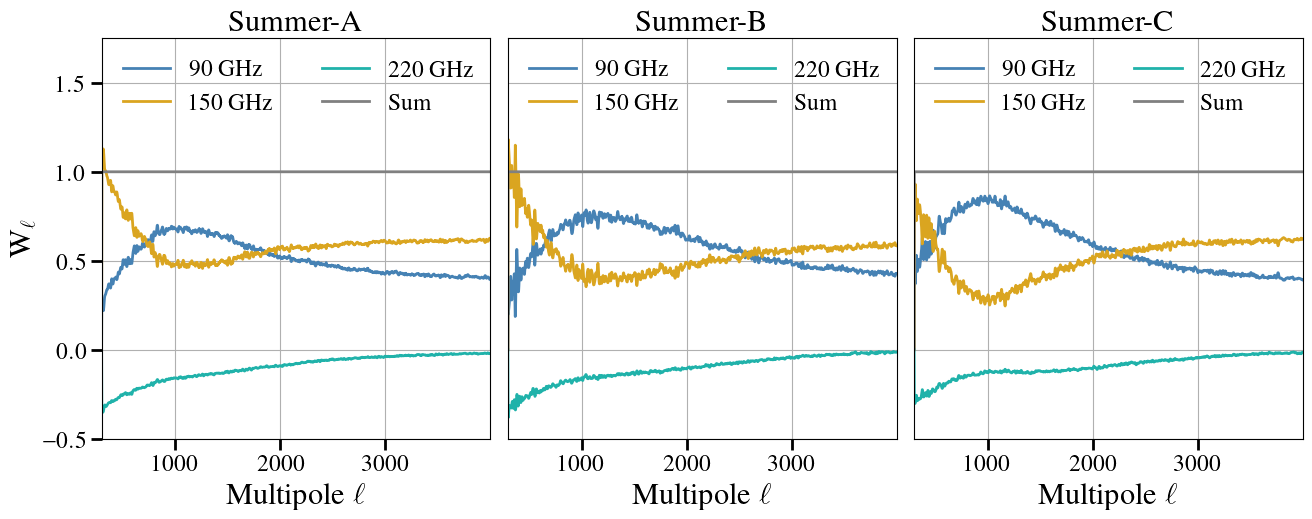

In [4]:
ls_arr = ['-', '--', ':']
fig, ax_arr = plt.subplots(1, len(field_arr), sharey=True, figsize=(15.5,5.2))
plt.subplots_adjust(wspace = 0.045)
title_arr = ["Summer-A", "Summer-B", "Summer-C"]


for cntr, field in enumerate(field_arr):
    weights_sum_arr = []
    for frq_cntr, freq in enumerate(freq_arr):    
        curr_weights = weights_dic[field][frq_cntr][0]
        weights_sum_arr.append(curr_weights)
        els = np.arange(len(curr_weights))
        ax_arr[cntr].plot(els, curr_weights, color = color_arr[frq_cntr], label = str(freq)+' GHz', lw = 2)

    ax_arr[cntr].plot(els, np.sum(weights_sum_arr, axis=0), color = 'grey', label = 'Sum', lw = 2)
    ax_arr[cntr].grid()
    ax_arr[cntr].set_xlim(300, 3999) 
    ax_arr[cntr].set_xlabel(r'Multipole $\ell$', fontsize=labelsize+5)
    ax_arr[cntr].legend(fontsize=legendsize+2, frameon=False, loc='upper left', ncol=2)
    ax_arr[cntr].set_title(title_arr[cntr], fontsize=labelsize+5) 
    ax_arr[cntr].tick_params(which='major', labelsize = labelsize, length = 8, width = 2)
    ax_arr[cntr].tick_params(which='minor', labelsize = labelsize, length = 4, width = 1)
    
    

    if cntr==0:
        ax_arr[cntr].set_ylim(-0.5, 1.75)
        ax_arr[cntr].set_ylabel(r'W$_{\ell}$', fontsize=labelsize+5)

    else:
        ax_arr[cntr].tick_params(axis='y', which='major', length = 0, width = 0)
        ax_arr[cntr].tick_params(axis='y', which='minor', length = 0, width = 0)
        

plt.savefig(figures_dir+'ilc_weights.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

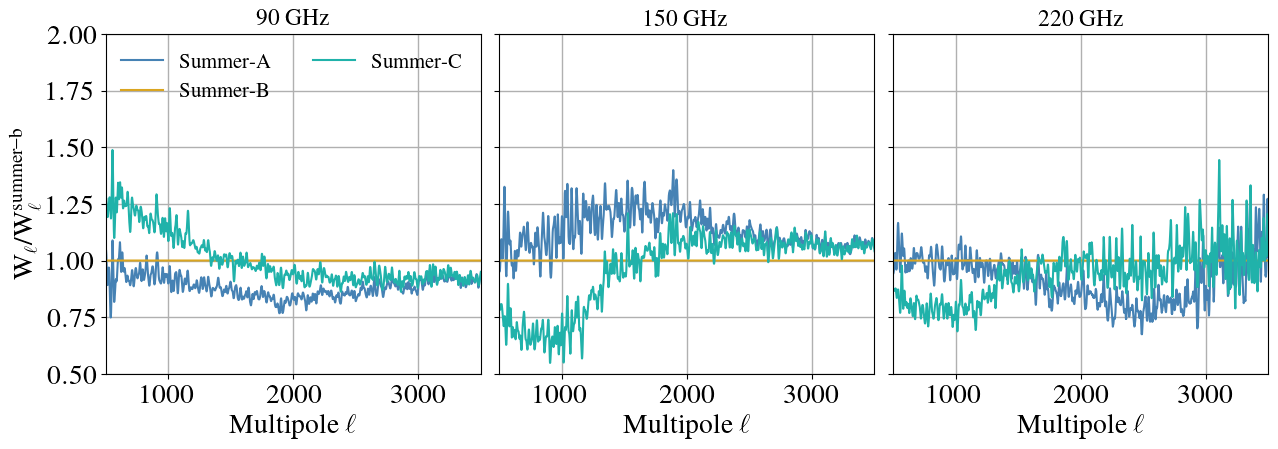

In [5]:
tr, tc = 3, 3
sbpl = 1
lwval = 2
summerfield_arr = ['summer_a', 'summer_b', 'summer_c']
freq_arr = ['90 GHz', '150 GHz', '220 GHz']

plt.figure(figsize=(15.,15.))
plt.subplots_adjust(hspace=0.2, wspace = 0.05)
for i, freq in enumerate(freq_arr):
    ax = plt.subplot(tr, tc, sbpl)
    for kcntr, summerfield in enumerate( summerfield_arr ):
        curr_weights = weights_dic[summerfield][i][0]
        els = np.arange(len(curr_weights))
        plt.plot(els, curr_weights/weights_dic["summer_b"][i][0], color = color_arr[kcntr], label = title_arr[kcntr], lw = 1.5)
    plt.xlim(500, 3500)
    plt.ylim(0.5, 2.)    
    plt.title(r'%s' %(freq), fontsize = labelsize)
    plt.grid(True, which = 'both', axis = 'both', lw = 1, alpha = 1)
    plt.xlabel(r'Multipole $\ell$'); 
    if (sbpl-1) % tc == 0:
        plt.ylabel(r'W$_{\ell}$/W$^{\rm summer-b}_{\ell}$')
        plt.legend(fontsize = legendsize, frameon=False, loc = 1, ncol = 2)
    else:
        plt.setp(ax.get_yticklabels(), visible=False)
    sbpl += 1

## ILC Residual Noise

In [6]:
field_arr=['summer-a', 'summer-b', 'summer-c']
residual_dic = {}
for field in field_arr:
    residual = np.loadtxt("/sptlocal/user/kevinlevy/summerfield_lensing/ilc/spectra/cl_residual_arr_cmbmv_%s.dat" %(field.replace("-", "_")), unpack=True)
    residual_dic[field] = residual[:lmax]

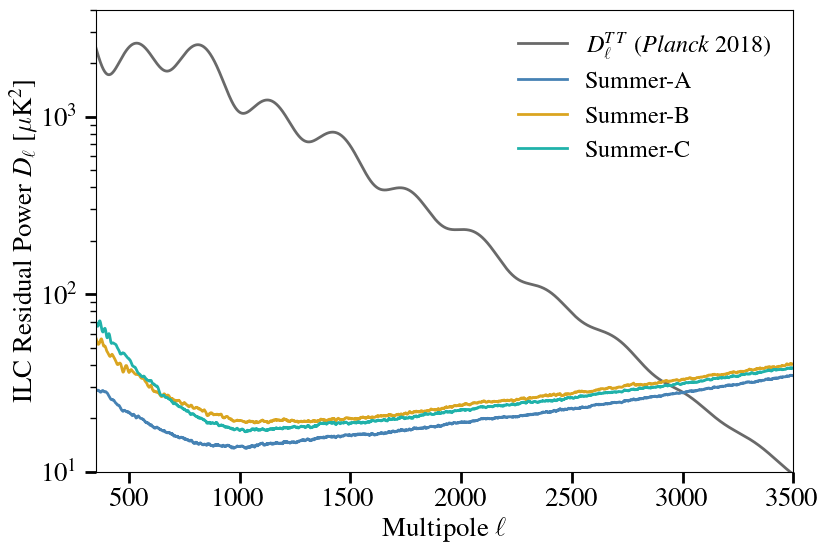

In [7]:
label_arr=['Summer-A', 'Summer-B', 'Summer-C']
fig, ax = plt.subplots(figsize = (9,6))

ax.plot(cls_theory/dl_fac, color=color_arr[-1], lw=2., label=r'$D_\ell^{TT}$ (\textit{Planck} 2018)')
for i, field in enumerate(field_arr):
    ax.plot(ell[:lmax], residual_dic[field]/dl_fac[:lmax], label=label_arr[i], color=color_arr[i], lw=2.)

ax.legend(fontsize=legendsize+2.5, frameon=False)
ax.set_ylabel(r'ILC Residual Power $D_\ell$ [$\mu$K$^2$]', fontsize=labelsize+2.5)
ax.set_xlabel(r'Multipole $\ell$', fontsize=labelsize+2.5)
ax.set_yscale('log')
ax.set_ylim(1e1, 4e3)
ax.set_xlim(350, 3500)
ax.tick_params(which='major', labelsize = labelsize+2.5, length = 8, width = 2)
ax.tick_params(which='minor', labelsize = labelsize+2.5, length = 4, width = 1)
plt.savefig(figures_dir+'ilc_residual_spectra.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

## ILC Maps

In [8]:
nbr_pix_dic = {"summer-a":[2100, 1750], "summer-b":[3150, 1140], "summer-c":[3150, 1140]}
ra_deg = 51
dec_deg = -37
radius_deg = 1.5
theta = np.radians(90 - dec_deg)  # colatitude
phi   = np.radians(ra_deg)
vec = hp.ang2vec(theta, phi)
pix1 = hp.query_disc(nside, vec, np.radians(radius_deg))

ra_deg = 73
dec_deg = -43
radius_deg = 3
theta = np.radians(90 - dec_deg)  # colatitude
phi   = np.radians(ra_deg)
vec = hp.ang2vec(theta, phi)
pix2 = hp.query_disc(nside, vec, np.radians(radius_deg))

arcmin = (1/60)*(np.pi/180)
bl_1deg = hp.gauss_beam(fwhm=30*arcmin) 
ilc_data_arr = []
for field in field_arr:
    ilc_map =hp.read_map('/sptlocal/user/kevinlevy/summerfield_lensing/ilc/maps/len/cmbmv/data/bundle0/cmbmv_tqu1_lmax4000_%s_seed0.fits'%(field.replace("-", "_")))
    ilc_map_flatsky = hp.gnomview(ilc_map*apod_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)
    ilc_data_arr.append(ilc_map_flatsky) 

ilc_sim_arr = []
for field in field_arr:
    ilc_map = hp.read_map('/sptlocal/user/kevinlevy/summerfield_lensing/ilc/maps/len/cmbmv/sims/bundle0/cmbmv_tqu1_lmax4000_%s_seed1.fits'%(field.replace("-", "_")))
    ilc_map_flatsky = hp.gnomview(ilc_map*apod_mask_dic[field], xsize=nbr_pix_dic[field][0], ysize=nbr_pix_dic[field][1], rot=(cntr_dic[field][0], cntr_dic[field][1], 0), return_projected_map=True, no_plot=True)
    ilc_sim_arr.append(ilc_map_flatsky) 

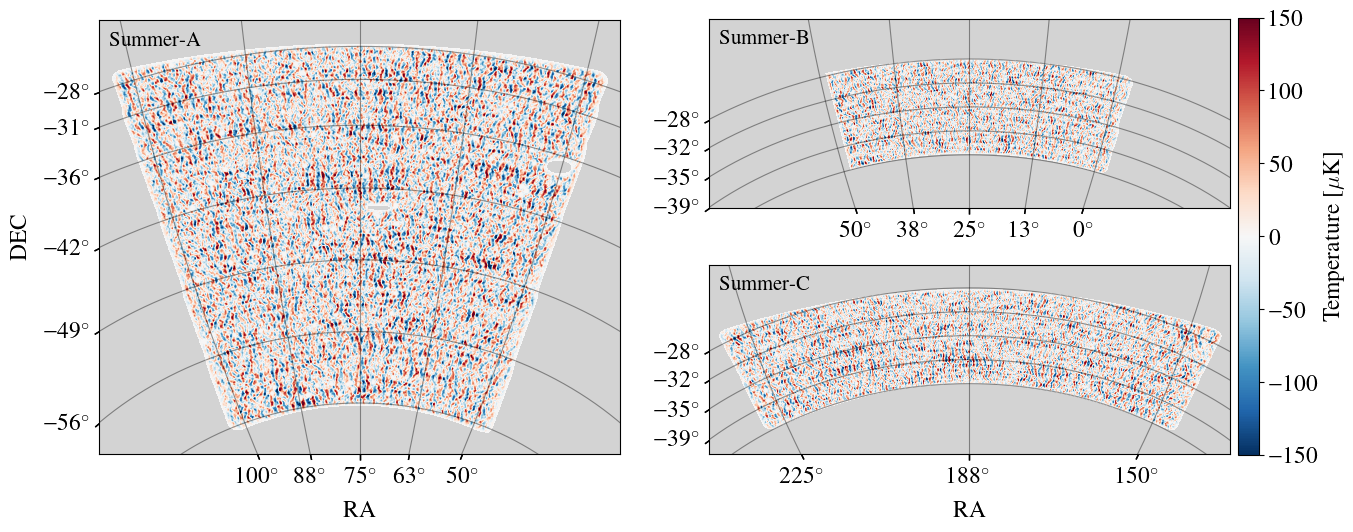

In [9]:
color_map_dic = {'summer-a':'YlGnBu_r', 'summer-b':'YlGnBu_r', 'summer-c':'YlGnBu_r'}
label_arr = ['', 'Convergence ' + r'$\kappa$', 'Convergence ' + r'$\kappa$']
vborder_arr = [[-150, 150], [-150, 150], [-150, 150]]
title_dic = {'summer-a':'Summer-A', 'summer-b':'Summer-B', 'summer-c':'Summer-C'}
label_arr = ['', '', 'Convergence ' + r'$\kappa$']
axis_label_arr = [[' RA', 'DEC'], [' ', ' '], ['RA', ' ']] 


cmap = cm.RdBu_r
cmap.set_bad(color='lightgrey')

fig = plt.figure(figsize=(16, 9))
gs = gridspec.GridSpec(2, 3, width_ratios=[1, 1, 0.04], height_ratios=[1, 1], wspace=0.25, hspace=-0.45) 

for i, field in enumerate(field_arr):

    hdr = fits.Header()
    hdr.set('NAXIS'   , 2)
    hdr.set('NAXIS1'  , nbr_pix_dic[field][0])
    hdr.set('NAXIS2'  , nbr_pix_dic[field][1])
    hdr.set('CTYPE1'  , 'RA---ZEA')
    hdr.set('CRPIX1'  , nbr_pix_dic[field][0]/2)
    hdr.set('CRVAL1'  , cntr_dic[field][0])
    hdr.set('CDELT1'  , -reso_arcmin*0.0166667)
    hdr.set('CUNIT1'  , 'deg')
    hdr.set('CTYPE2'  , 'DEC--ZEA')
    hdr.set('CRPIX2'  , nbr_pix_dic[field][1]/2)
    hdr.set('CRVAL2'  , cntr_dic[field][1]) 
    hdr.set('CDELT2'  , reso_arcmin*0.0166667)
    hdr.set('CUNIT2'  , 'deg')
    hdr.set('COORDSYS','icrs')
        
    w = WCS(hdr)
    if i ==0:
        ax = fig.add_subplot(gs[:, 0], projection=w)
        ax.text(40, 1700, title_dic[field], color='black', fontsize=legendsize, fontweight='bold', ha='left', va='top')  
        im0 = ax.imshow(ilc_data_arr[i], cmap = cmap, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    if i ==1:
        ax = fig.add_subplot(gs[0, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='black', fontsize=legendsize, fontweight='bold', ha='left', va='top') 
    if i ==2:
        ax = fig.add_subplot(gs[1, 1], projection=w)
        ax.text(60, 1080, title_dic[field], color='black', fontsize=legendsize, fontweight='bold', ha='left', va='top') 

    im = ax.imshow(ilc_data_arr[i], cmap = cmap, vmin=vborder_arr[i][0], vmax=vborder_arr[i][1], origin=origin_arr[i])
    ax.set_xlabel(axis_label_arr[i][0], fontsize = labelsize)
    ax.set_ylabel(axis_label_arr[i][1], fontsize = labelsize)
    
    ax.tick_params(direction='out', axis='x', length=4, width=1, which = 'major', top = False, bottom = True, labelsize = labelsize)
    ax.tick_params(direction='out', axis='y', length=4, width=1, which = 'major', left = True,right = False, labelsize = labelsize)
    ax.grid(color='black', ls='solid',alpha=0.4)
    
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('b')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')


cax = fig.add_subplot(gs[:, 2])  

pos = cax.get_position()

cax.set_position([
    pos.x0-0.05,           
    pos.y0+0.1425,    
    pos.width,        
    pos.height*0.631])

cb = fig.colorbar(im0, cax=cax)   
cb.set_label(label='Temperature ' + r'[$\mu$K]', fontsize = labelsize)
cb.ax.tick_params(labelsize=labelsize) 

plt.savefig(figures_dir+'ilc_maps.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

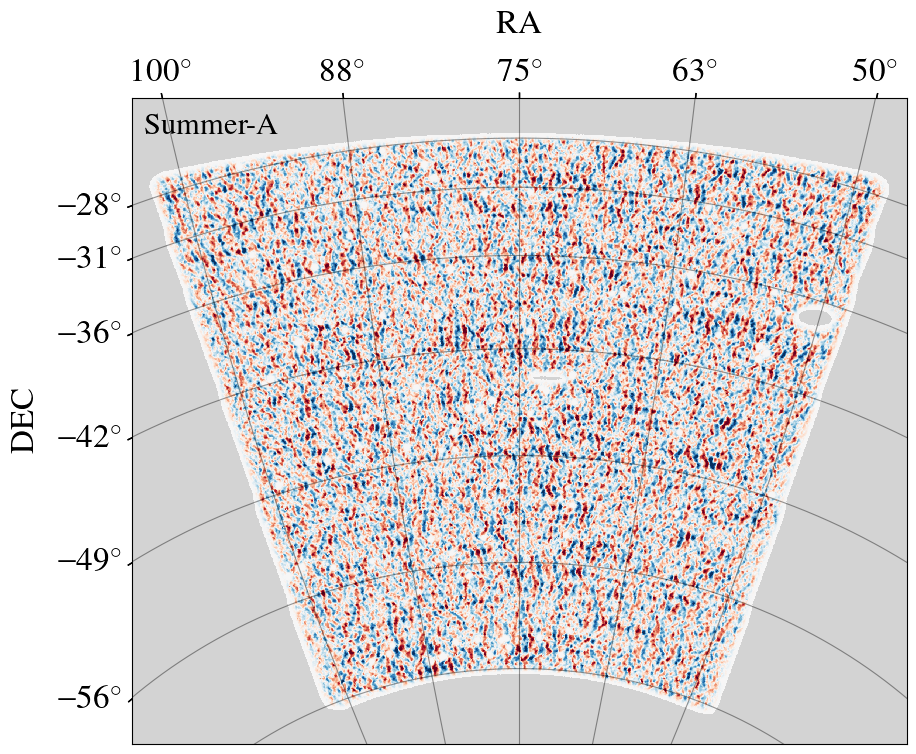

In [10]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

i=0
field_arr = ['summer-a']

# Fixed figure dimensions: same width for all, taller for 3 stacked plots
fig = plt.figure(figsize=(10, 12))  
gs = gridspec.GridSpec(len(field_arr), 1, hspace=0.3)  # equal spacing

for field in field_arr:
    # ---- Create WCS header ----
    hdr = fits.Header()
    hdr.set('NAXIS', 2)
    hdr.set('NAXIS1', nbr_pix_dic[field][0])
    hdr.set('NAXIS2', nbr_pix_dic[field][1])
    hdr.set('CTYPE1', 'RA---ZEA')
    hdr.set('CRPIX1', nbr_pix_dic[field][0] / 2)
    hdr.set('CRVAL1', cntr_dic[field][0])
    hdr.set('CDELT1', -reso_arcmin * 0.0166667)
    hdr.set('CUNIT1', 'deg')
    hdr.set('CTYPE2', 'DEC--ZEA')
    hdr.set('CRPIX2', nbr_pix_dic[field][1] / 2)
    hdr.set('CRVAL2', cntr_dic[field][1])
    hdr.set('CDELT2', reso_arcmin * 0.0166667)
    hdr.set('CUNIT2', 'deg')
    hdr.set('COORDSYS', 'icrs')

    w = WCS(hdr)

    # ---- Create subplot ----
    ax = fig.add_subplot(gs[0, 0], projection=w, aspect='equal')

    # ---- Plot map ----
    im = ax.imshow(
        ilc_data_arr[i],
        cmap=cmap,
        vmin=vborder_arr[i][0],
        vmax=vborder_arr[i][1],
        origin=origin_arr[i],
        interpolation='none')

    # ---- Title ----
    ax.text(35, 1710, title_dic[field], color='black', fontsize=legendsize+7, fontweight='bold', ha='left', va='top') 

    # ---- Move x-axis ticks and label to top ----
    ax.tick_params(
        direction='out',
        axis='x',
        length=4,
        width=1,
        which='major',
        top=True,
        bottom=False,  # disable bottom ticks
        labeltop=True,  # enable top tick labels
        labelbottom=False,
        labelsize=labelsize+7
    )
    
    ax.xaxis.set_label_position('top')  # move label to top
    ax.set_xlabel(axis_label_arr[0][0], fontsize=labelsize+7)
    
    # ---- Y-axis ticks ----
    ax.tick_params(
        direction='out',
        axis='y',
        length=4,
        width=1,
        which='major',
        left=True,
        right=False,
        labelsize=labelsize+7
    )
    ax.set_ylabel(axis_label_arr[0][1], fontsize=labelsize+7)

    ax.grid(color='black', ls='solid', alpha=0.4)

    # ---- Coordinate formatting ----
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('t')
    lon.set_axislabel_position('t')   # move RA label to top
    lat.set_axislabel_position('l')   # keep DEC label on left
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')
  

plt.savefig(figures_dir+'ilc_map_summera.pdf', dpi=250, bbox_inches='tight', pad_inches=0.1)

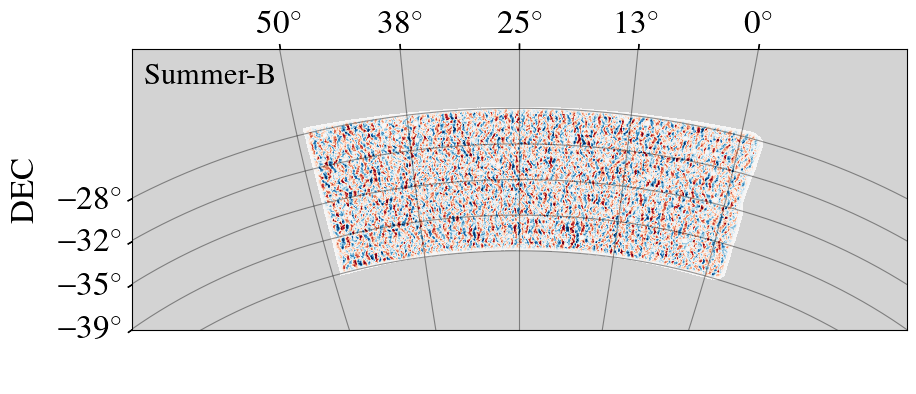

In [11]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

i=1
field_arr = ['summer-b']

# Fixed figure dimensions: same width for all, taller for 3 stacked plots
fig = plt.figure(figsize=(10, 12))  
gs = gridspec.GridSpec(len(field_arr), 1, hspace=0.3)  # equal spacing

for field in field_arr:
    # ---- Create WCS header ----
    hdr = fits.Header()
    hdr.set('NAXIS', 2)
    hdr.set('NAXIS1', nbr_pix_dic[field][0])
    hdr.set('NAXIS2', nbr_pix_dic[field][1])
    hdr.set('CTYPE1', 'RA---ZEA')
    hdr.set('CRPIX1', nbr_pix_dic[field][0] / 2)
    hdr.set('CRVAL1', cntr_dic[field][0])
    hdr.set('CDELT1', -reso_arcmin * 0.0166667)
    hdr.set('CUNIT1', 'deg')
    hdr.set('CTYPE2', 'DEC--ZEA')
    hdr.set('CRPIX2', nbr_pix_dic[field][1] / 2)
    hdr.set('CRVAL2', cntr_dic[field][1])
    hdr.set('CDELT2', reso_arcmin * 0.0166667)
    hdr.set('CUNIT2', 'deg')
    hdr.set('COORDSYS', 'icrs')

    w = WCS(hdr)

    # ---- Create subplot ----
    ax = fig.add_subplot(gs[0, 0], projection=w, aspect='equal')

    # ---- Plot map ----
    im = ax.imshow(
        ilc_data_arr[i],
        cmap=cmap,
        vmin=vborder_arr[i][0],
        vmax=vborder_arr[i][1],
        origin=origin_arr[i],
        interpolation='none')

    # ---- Title ----
    ax.text(55, 1085, title_dic[field], color='black', fontsize=legendsize+7, fontweight='bold', ha='left', va='top') 

    # ---- Move x-axis ticks and label to top ----
    ax.tick_params(
        direction='out',
        axis='x',
        length=4,
        width=1,
        which='major',
        top=True,
        bottom=False,  # disable bottom ticks
        labeltop=True,  # enable top tick labels
        labelbottom=False,
        labelsize=labelsize+7
    )
    ax.xaxis.set_label_position('top')  # move label to top
    ax.set_xlabel(axis_label_arr[1][1], fontsize=labelsize+10)

    # ---- Y-axis ticks ----
    ax.tick_params(
        direction='out',
        axis='y',
        length=4,
        width=1,
        which='major',
        left=True,
        right=False,
        labelsize=labelsize+7
    )
    ax.set_ylabel(axis_label_arr[0][1], fontsize=labelsize+7)

    ax.grid(color='black', ls='solid', alpha=0.4)

    # ---- Coordinate formatting ----
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('t')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')

plt.savefig(figures_dir+'ilc_map_summerb.pdf', dpi=250, bbox_inches='tight', pad_inches=0.1)

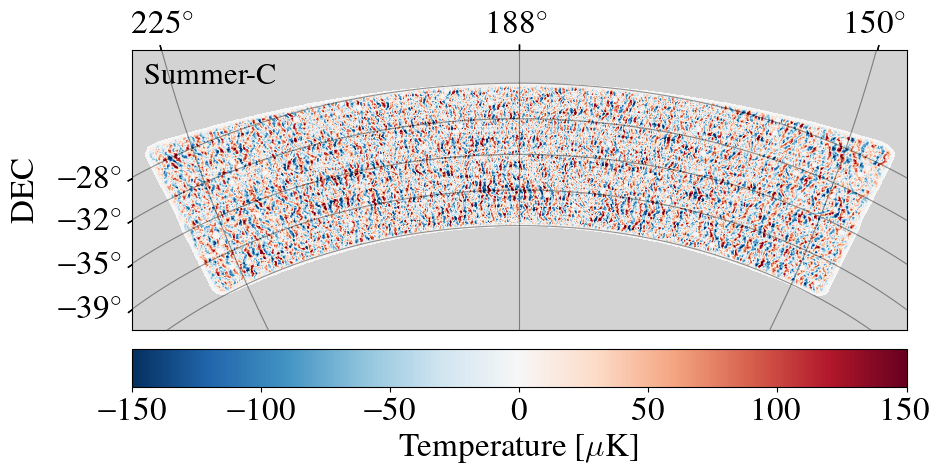

In [12]:
import matplotlib.pyplot as plt
from matplotlib import gridspec
from astropy.io import fits
from astropy.wcs import WCS
import astropy.units as u

i=2
field_arr = ['summer-c']

fig = plt.figure(figsize=(10, 12))  
gs = gridspec.GridSpec(len(field_arr), 1, hspace=0.3)  # equal spacing

for field in field_arr:
    # ---- Create WCS header ----
    hdr = fits.Header()
    hdr.set('NAXIS', 2)
    hdr.set('NAXIS1', nbr_pix_dic[field][0])
    hdr.set('NAXIS2', nbr_pix_dic[field][1])
    hdr.set('CTYPE1', 'RA---ZEA')
    hdr.set('CRPIX1', nbr_pix_dic[field][0] / 2)
    hdr.set('CRVAL1', cntr_dic[field][0])
    hdr.set('CDELT1', -reso_arcmin * 0.0166667)
    hdr.set('CUNIT1', 'deg')
    hdr.set('CTYPE2', 'DEC--ZEA')
    hdr.set('CRPIX2', nbr_pix_dic[field][1] / 2)
    hdr.set('CRVAL2', cntr_dic[field][1])
    hdr.set('CDELT2', reso_arcmin * 0.0166667)
    hdr.set('CUNIT2', 'deg')
    hdr.set('COORDSYS', 'icrs')

    w = WCS(hdr)

    # ---- Create subplot ----
    ax = fig.add_subplot(gs[0, 0], projection=w, aspect='equal')

    # ---- Plot map ----
    im = ax.imshow(
        ilc_data_arr[i],
        cmap=cmap,
        vmin=vborder_arr[i][0],
        vmax=vborder_arr[i][1],
        origin=origin_arr[i],
        interpolation='none')

    # ---- Title ----
    ax.text(55, 1085, title_dic[field], color='black', fontsize=legendsize+7, fontweight='bold', ha='left', va='top') 

    # ---- Move x-axis ticks and label to top ----
    ax.tick_params(
        direction='out',
        axis='x',
        length=4,
        width=1,
        which='major',
        top=True,
        bottom=False,  # disable bottom ticks
        labeltop=True,  # enable top tick labels
        labelbottom=False,
        labelsize=labelsize+7
    )
    ax.xaxis.set_label_position('top')  # move label to top
    ax.set_xlabel(axis_label_arr[1][1], fontsize=labelsize+10)

    # ---- Y-axis ticks ----
    ax.tick_params(
        direction='out',
        axis='y',
        length=4,
        width=1,
        which='major',
        left=True,
        right=False,
        labelsize=labelsize+7
    )
    ax.set_ylabel(axis_label_arr[0][1], fontsize=labelsize+7)

    ax.grid(color='black', ls='solid', alpha=0.4)

    # ---- Coordinate formatting ----
    lon, lat = ax.coords
    lat.set_ticklabel_position('l')
    lon.set_ticklabel_position('t')
    lon.set_ticks(ra_dic[field] * u.degree)
    lon.set_major_formatter('dd')
    lat.set_ticks(dec_dic[field] * u.degree)
    lat.set_major_formatter('dd')

    # ---- Individual colorbar (horizontal above each plot) ----
    cbar = fig.colorbar(im, ax=ax, orientation='horizontal', pad=0.02)
    cbar.set_label(label='Temperature ' + r'[$\mu$K]', fontsize=labelsize+7)
    cbar.ax.tick_params(labelsize=labelsize+7)
    cbar.ax.xaxis.set_label_position('bottom')
    cbar.ax.xaxis.set_ticks_position('bottom')

plt.savefig(figures_dir+'ilc_map_summerc.pdf', dpi=250, bbox_inches='tight', pad_inches=0.1)
field_arr = ['summer-a','summer-b','summer-c']

## ILC Spectra

In [13]:
import curved_sky 

def get_cl_from_polspice(m1, m2 = None, mask = None, bl1 = None, bl2 = None, 
                         lmin = 0, lmax = 4000, bin_width = 1, 
                         return_mask = False, return_error = False, return_kernel = False,
                         pixwin = 'NO', pixwin_lab = 'False', lfac = 0, 
                         verbose = True, symmetric_cl = 0, apodizetype = 1, 
                         apodizesigma = 30, thetamax = 30, tolerance = 1.e-08):
    
    binned_el, binned_cl = curved_sky.spectrum_spice(
            map1=m1, 
            map2=m2, 
            lmin=lmin, 
            lmax=lmax, 
            bin_width=bin_width,
            return_mask=return_mask,
            mask=mask,
            return_error=return_error,
            return_kernel=return_kernel, 
            lfac=lfac, 
            verbose=verbose,
            beam=bl1,
            pixwin=pixwin,
            beam2=bl2,
            pixwin2=pixwin,
            symmetric_cl=symmetric_cl,
            apodizetype=apodizetype,
            apodizesigma=apodizesigma,
            thetamax=thetamax,
            tolerance=tolerance)

    return binned_el, binned_cl


cls_data_dic = {}
for i, field in enumerate(field_arr):
    ilc_map = hp.read_map('/sptlocal/user/kevinlevy/summerfield_lensing/ilc/maps/len/cmbmv/data/bundle0/cmbmv_tqu1_lmax4000_%s_seed0.fits'%(field.replace("-", "_")))
    binned_el, binned_cl = get_cl_from_polspice(ilc_map, mask = ps20mJy_mask_dic[field])   
    cls_data_dic[field] = binned_cl

cls_sims_dic = {}
for i, field in enumerate(field_arr):
    ilc_map = hp.read_map('/sptlocal/user/kevinlevy/summerfield_lensing/ilc/maps/len/cmbmv/sims/bundle0/cmbmv_tqu1_lmax4000_%s_seed1.fits'%(field.replace("-", "_")))
    binned_el, binned_cl = get_cl_from_polspice(ilc_map, mask = ps20mJy_mask_dic[field])
    cls_sims_dic[field] = binned_cl

setting the output map dtype to [dtype('>f8')]
setting the output map dtype to [dtype('>f8')]


 ===> Using HEALPIXDATA=/cvmfs/spt.opensciencegrid.org/py3-v4/RHEL_9_x86_64/share/healpix/

 SpICE 3.7.5_DP has been called with the following attributes : 

 nside detected...         2048
 max multipole used        4000
 polarization..... NO
 map file (1)......
     1.000 *   /tmp/tmptjw9byr7/map.fits
 mask file....(T)..NO
 weight file..(T)../tmp/tmptjw9byr7/weight.fits
 weight power.....    1.0000000000000000     
 dump alm(1)...... NO
 weight alm(1).... NO
 gauss beam arcmin NO
 beam file........ NO
 pix. window file. NO
 subtract dipole.. NO
 subtract average. NO
 cor. file........ NO
 Cl file.......... /tmp/tmptjw9byr7/cl.fits
 Covariance file.. NO
 raw Cl map output NO
 raw Cl map input  NO
 raw Cl mask outp. NO
 raw Cl mask inpu. NO
 FITS output...... YES
 norm. factor..... NO
 apodizing width..     3.00000E+01
 apodizing type...            1
 decouple......... NO
 thetamax.........    30.000000000000000     
 kernels output... NO
 window output.... NO
 window input..... NO
 TE

setting the output map dtype to [dtype('>f8')]
setting the output map dtype to [dtype('>f8')]


 ===> Using HEALPIXDATA=/cvmfs/spt.opensciencegrid.org/py3-v4/RHEL_9_x86_64/share/healpix/

 SpICE 3.7.5_DP has been called with the following attributes : 

 nside detected...         2048
 max multipole used        4000
 polarization..... NO
 map file (1)......
     1.000 *   /tmp/tmps8k_m6cm/map.fits
 mask file....(T)..NO
 weight file..(T)../tmp/tmps8k_m6cm/weight.fits
 weight power.....    1.0000000000000000     
 dump alm(1)...... NO
 weight alm(1).... NO
 gauss beam arcmin NO
 beam file........ NO
 pix. window file. NO
 subtract dipole.. NO
 subtract average. NO
 cor. file........ NO
 Cl file.......... /tmp/tmps8k_m6cm/cl.fits
 Covariance file.. NO
 raw Cl map output NO
 raw Cl map input  NO
 raw Cl mask outp. NO
 raw Cl mask inpu. NO
 FITS output...... YES
 norm. factor..... NO
 apodizing width..     3.00000E+01
 apodizing type...            1
 decouple......... NO
 thetamax.........    30.000000000000000     
 kernels output... NO
 window output.... NO
 window input..... NO
 TE

setting the output map dtype to [dtype('>f8')]
setting the output map dtype to [dtype('>f8')]


...

 ===> Using HEALPIXDATA=/cvmfs/spt.opensciencegrid.org/py3-v4/RHEL_9_x86_64/share/healpix/

 SpICE 3.7.5_DP has been called with the following attributes : 

 nside detected...         2048
 max multipole used        4000
 polarization..... NO
 map file (1)......
     1.000 *   /tmp/tmpqxj31ws9/map.fits
 mask file....(T)..NO
 weight file..(T)../tmp/tmpqxj31ws9/weight.fits
 weight power.....    1.0000000000000000     
 dump alm(1)...... NO
 weight alm(1).... NO
 gauss beam arcmin NO
 beam file........ NO
 pix. window file. NO
 subtract dipole.. NO
 subtract average. NO
 cor. file........ NO
 Cl file.......... /tmp/tmpqxj31ws9/cl.fits
 Covariance file.. NO
 raw Cl map output NO
 raw Cl map input  NO
 raw Cl mask outp. NO
 raw Cl mask inpu. NO
 FITS output...... YES
 norm. factor..... NO
 apodizing width..     3.00000E+01
 apodizing type...            1
 decouple......... NO
 thetamax.........    30.000000000000000     
 kernels output... NO
 window output.... NO
 window input..... NO
 TE

setting the output map dtype to [dtype('>f8')]
setting the output map dtype to [dtype('>f8')]


 ===> Using HEALPIXDATA=/cvmfs/spt.opensciencegrid.org/py3-v4/RHEL_9_x86_64/share/healpix/

 SpICE 3.7.5_DP has been called with the following attributes : 

 nside detected...         2048
 max multipole used        4000
 polarization..... NO
 map file (1)......
     1.000 *   /tmp/tmp4l7cbi57/map.fits
 mask file....(T)..NO
 weight file..(T)../tmp/tmp4l7cbi57/weight.fits
 weight power.....    1.0000000000000000     
 dump alm(1)...... NO
 weight alm(1).... NO
 gauss beam arcmin NO
 beam file........ NO
 pix. window file. NO
 subtract dipole.. NO
 subtract average. NO
 cor. file........ NO
 Cl file.......... /tmp/tmp4l7cbi57/cl.fits
 Covariance file.. NO
 raw Cl map output NO
 raw Cl map input  NO
 raw Cl mask outp. NO
 raw Cl mask inpu. NO
 FITS output...... YES
 norm. factor..... NO
 apodizing width..     3.00000E+01
 apodizing type...            1
 decouple......... NO
 thetamax.........    30.000000000000000     
 kernels output... NO
 window output.... NO
 window input..... NO
 TE

setting the output map dtype to [dtype('>f8')]
setting the output map dtype to [dtype('>f8')]


 ===> Using HEALPIXDATA=/cvmfs/spt.opensciencegrid.org/py3-v4/RHEL_9_x86_64/share/healpix/

 SpICE 3.7.5_DP has been called with the following attributes : 

 nside detected...         2048
 max multipole used        4000
 polarization..... NO
 map file (1)......
     1.000 *   /tmp/tmp8uvaoz57/map.fits
 mask file....(T)..NO
 weight file..(T)../tmp/tmp8uvaoz57/weight.fits
 weight power.....    1.0000000000000000     
 dump alm(1)...... NO
 weight alm(1).... NO
 gauss beam arcmin NO
 beam file........ NO
 pix. window file. NO
 subtract dipole.. NO
 subtract average. NO
 cor. file........ NO
 Cl file.......... /tmp/tmp8uvaoz57/cl.fits
 Covariance file.. NO
 raw Cl map output NO
 raw Cl map input  NO
 raw Cl mask outp. NO
 raw Cl mask inpu. NO
 FITS output...... YES
 norm. factor..... NO
 apodizing width..     3.00000E+01
 apodizing type...            1
 decouple......... NO
 thetamax.........    30.000000000000000     
 kernels output... NO
 window output.... NO
 window input..... NO
 TE

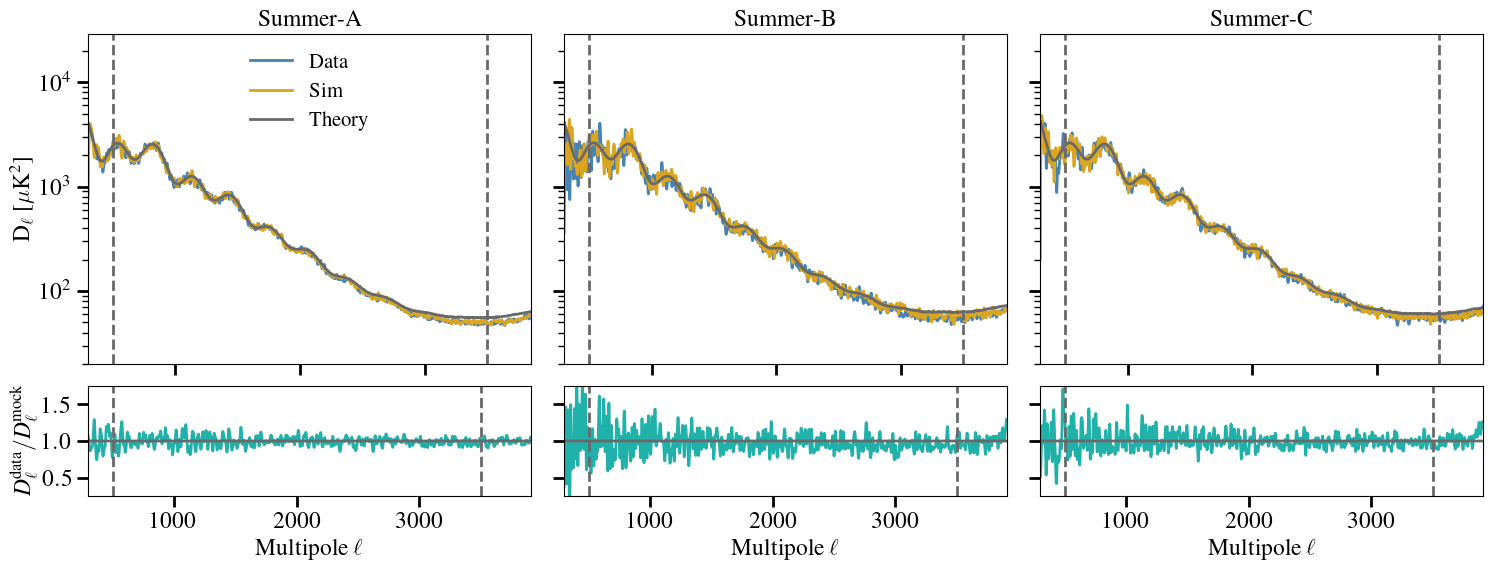

In [14]:
tr, tc = 3, 3
sbpl = 1
lmax=4000
beam_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/'
beam_file = 'compiled_2020_beam_freqghz.npy'
bl = np.load(beam_loc+beam_file.replace('freq', str(150)))[:lmax]
pixwin=hp.pixwin(2048)[:lmax]
fig, ax_arr = plt.subplots(ncols=3, nrows=2, figsize = (18,6), constrained_layout=True, gridspec_kw={'height_ratios':[3,1]}) 
plt.subplots_adjust(hspace=0.1, wspace=0.075)
title_arr = ['Summer-A', 'Summer-B', 'Summer-C']

for cntr, field in enumerate(field_arr):
    ax_arr[0][cntr].plot(binned_el[:lmax],  (cls_data_dic[field][:lmax])*bl**-2*pixwin**-2/dl_fac[:lmax], color = color_arr[0], label='Data', lw = 2.)
    ax_arr[0][cntr].plot(binned_el[:lmax],  (cls_sims_dic[field][:lmax])*bl**-2*pixwin**-2/dl_fac[:lmax], color = color_arr[1], label='Sim', lw = 2.)
    ax_arr[0][cntr].plot(ell[:lmax], (cls_theory[:lmax]+residual_dic[field]*pixwin**-2)/dl_fac[:lmax], color=color_arr[-1], label='Theory', lw = 2.)
    ax_arr[0][cntr].set_xlim(300, 3850)

    ax_arr[0][cntr].set_title(title_arr[cntr], fontsize=labelsize) 
    ax_arr[0][cntr].set_ylim(2e1, 2.9e4)
    ax_arr[0][cntr].set_yscale('log')

    if cntr==0:        
        ax_arr[0][cntr].set_ylabel(r'D$_{\ell}$ [$\mu$K$^{2}$]', fontsize=labelsize)
        ax_arr[0][cntr].legend(fontsize = legendsize, frameon=False, loc = 'upper center')
        ax_arr[0][cntr].tick_params(which='major', labelsize = labelsize, length = 8, width = 2)
        ax_arr[0][cntr].tick_params(which='minor', labelsize = labelsize, length = 4, width = 1)
    else:
        ax_arr[0][cntr].tick_params(which='major', labelsize = labelsize, length = 8, width = 2, labelleft=False)
        ax_arr[0][cntr].tick_params(which='minor', labelsize = labelsize, length = 4, width = 1, labelleft=False)


    ax_arr[0][cntr].axvline(500, ls='--', color=color_arr[-1], lw = 2.)
    ax_arr[0][cntr].axvline(3500, ls='--', color=color_arr[-1], lw = 2.)
    ax_arr[0][cntr].set_xticklabels([])
    
    ax_arr[1][cntr].plot(binned_el,  cls_data_dic[field]/cls_sims_dic[field], color = color_arr[2], lw = 2.)
    ax_arr[1][cntr].plot(ell, cls_theory/cls_theory, color=color_arr[-1], lw = 2.)
    ax_arr[1][cntr].set_xlabel(r'Multipole $\ell$', fontsize=labelsize)
    ax_arr[1][cntr].set_ylim(0.25, 1.75)
    ax_arr[1][cntr].set_xlim(300, 3910)

    if cntr==0: 
        ax_arr[1][cntr].set_ylabel(r'$D_\ell^{\rm data}/D_\ell^{\rm mock}$', fontsize=labelsize)
        ax_arr[1][cntr].tick_params(which='major', labelsize = labelsize, length = 8, width = 2)
        ax_arr[1][cntr].tick_params(which='minor', labelsize = labelsize, length = 4, width = 1)
    else:
        ax_arr[1][cntr].tick_params(which='major', labelsize = labelsize, length = 8, width = 2, labelleft=False)
        ax_arr[1][cntr].tick_params(which='minor', labelsize = labelsize, length = 4, width = 1, labelleft=False)
    
    ax_arr[1][cntr].axvline(500, ls='--', color=color_arr[-1], lw = 2.)
    ax_arr[1][cntr].axvline(3500, ls='--', color=color_arr[-1], lw = 2.)
    

plt.savefig(figures_dir+'ilc_spectra.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)

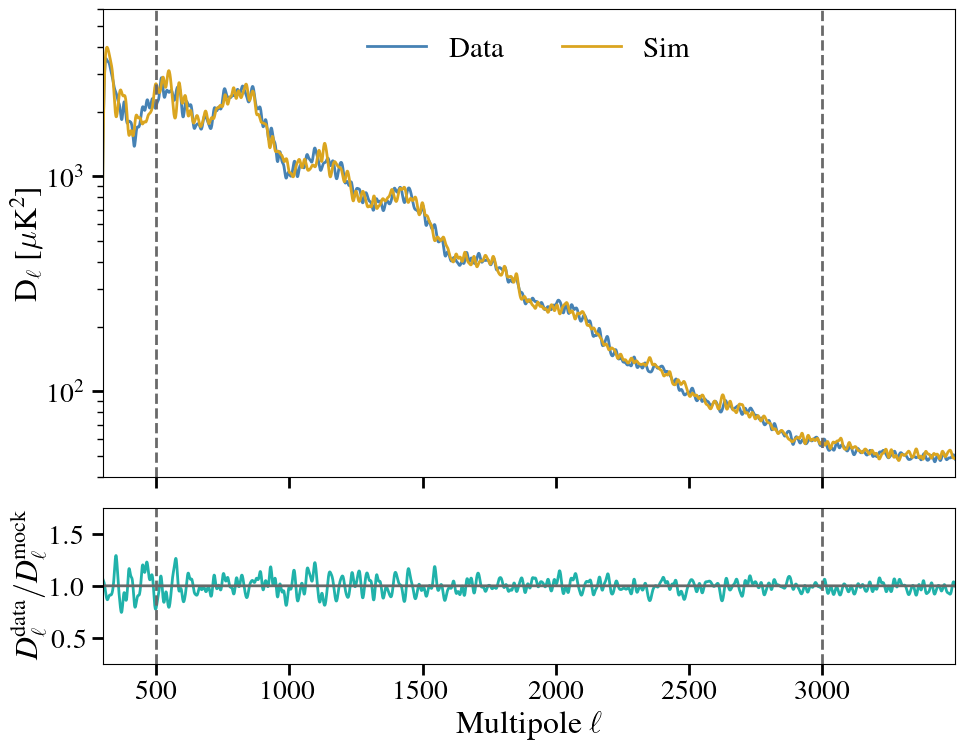

In [15]:
tr, tc = 3, 3
sbpl = 1
lmax=4000
beam_loc = '/sptlocal/user/kevinlevy/summerfield_lensing/data/beams/'
beam_file = 'compiled_2020_beam_freqghz.npy'
bl = np.load(beam_loc+beam_file.replace('freq', str(150)))[:lmax]
pixwin=hp.pixwin(2048)[:lmax]
fig, ax_arr = plt.subplots(ncols=1, nrows=2, figsize = (11,8.5), constrained_layout=True, gridspec_kw={'height_ratios':[3,1]}) 
plt.subplots_adjust(hspace=0.1, wspace=0.075)
title_arr = ['Summer-A', 'Summer-B', 'Summer-C']

for cntr, field in enumerate(['summer-a']):
    ax_arr[0].plot(binned_el[:lmax],  (cls_data_dic[field][:lmax])*bl**-2*pixwin**-2/dl_fac[:lmax], color = color_arr[0], label='Data', lw = 2.)
    ax_arr[0].plot(binned_el[:lmax],  (cls_sims_dic[field][:lmax])*bl**-2*pixwin**-2/dl_fac[:lmax], color = color_arr[1], label='Sim', lw = 2.)
    ax_arr[0].set_xlim(300, 3499)
    ax_arr[0].set_ylim(4e1,6e3)
    ax_arr[0].set_yscale('log')

    if cntr==0:        
        ax_arr[0].set_ylabel(r'D$_{\ell}$ [$\mu$K$^{2}$]', fontsize=labelsize+6)
        ax_arr[0].legend(fontsize = legendsize+6, frameon=False, loc = 'upper center', ncol=2)
        ax_arr[0].tick_params(which='major', labelsize = labelsize+3, length = 8, width = 2)
        ax_arr[0].tick_params(which='minor', labelsize = labelsize+3, length = 4, width = 1)
    else:
        ax_arr[0].tick_params(which='major', labelsize = labelsize+3, length = 8, width = 2, labelleft=False)
        ax_arr[0].tick_params(which='minor', labelsize = labelsize+3, length = 4, width = 1, labelleft=False)

    ax_arr[0].axvline(500, ls='--', color=color_arr[-1], lw = 2.)
    ax_arr[0].axvline(3000, ls='--', color=color_arr[-1], lw = 2.)
    ax_arr[0].set_xticklabels([])
    
    ax_arr[1].plot(binned_el,  cls_data_dic[field]/cls_sims_dic[field], color = color_arr[2], lw = 2.)
    ax_arr[1].plot(ell, cls_theory/cls_theory, color=color_arr[-1], lw = 2.)
    ax_arr[1].set_xlabel(r'Multipole $\ell$', fontsize=labelsize+6)
    ax_arr[1].set_ylim(0.25, 1.75)
    ax_arr[1].set_xlim(300, 3499)

    if cntr==0: 
        ax_arr[1].set_ylabel(r'$D_\ell^{\rm data}/D_\ell^{\rm mock}$', fontsize=labelsize+6)
        ax_arr[1].tick_params(which='major', labelsize = labelsize+3, length = 8, width = 2)
        ax_arr[1].tick_params(which='minor', labelsize = labelsize+3, length = 4, width = 1)
    else:
        ax_arr[1].tick_params(which='major', labelsize = labelsize+3, length = 8, width = 2, labelleft=False)
        ax_arr[1].tick_params(which='minor', labelsize = labelsize+3, length = 4, width = 1, labelleft=False)
    
    ax_arr[1].axvline(500, ls='--', color=color_arr[-1], lw = 2.)
    ax_arr[1].axvline(3000, ls='--', color=color_arr[-1], lw = 2.)

plt.savefig(figures_dir+'ilc_spectra_summera.pdf', dpi = 250., bbox_inches = 'tight', pad_inches = 0.1)